# 1) Chargement des données

Allez, cadeau 😘:

In [7]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DATA_PATH = "billets.csv"

if not os.path.exists(DATA_PATH):
    print(f"❌ Attention : le fichier '{DATA_PATH}' n'existe pas.")

try:
    df = pd.read_csv(DATA_PATH, sep=";")
    print("✅ Données chargées :", df.shape)
    display(df.head())
except Exception as e:
    print("❌ Erreur lors du chargement :", e)
    print("⚠️ Tu as bien lu le code avant de l'executer ? 😏")


✅ Données chargées : (1500, 7)


,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length
0,True,171.81,104.86,104.95,4.52,2.89,112.83
1,True,171.46,103.36,103.66,3.77,2.99,113.09
2,True,172.69,104.48,103.50,4.40,2.94,113.16
3,True,171.36,103.91,103.94,3.62,3.01,113.51
4,True,171.73,104.28,103.46,4.04,3.48,112.54


In [108]:
sns.set()

# 2) Analyse exploratoire (EDA)


Là, c'est vous les pro 💪, je vous fais entièrement confiance 😉 !

Pssst (indice) : trouvez des variables corrélées à votre objectif, ça marche mieux 😉.

## 2.1) Découverte des données

In [19]:
print(f"Le fichier comporte {df.shape[0]} observations et {df.shape[1]} colonnes. Les colonnes en question sont: {', '.join(df.columns)}.")
for column in df.columns:
    print("-", column)

Le fichier comporte 1500 observations et 7 colonnes. Les colonnes en question sont: is_genuine, diagonal, height_left, height_right, margin_low, margin_up, length.
- is_genuine
- diagonal
- height_left
- height_right
- margin_low
- margin_up
- length


Jetons un oeil aux premières lignes du DataFrame:


In [22]:
df.head()

,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length
0,True,171.81,104.86,104.95,4.52,2.89,112.83
1,True,171.46,103.36,103.66,3.77,2.99,113.09
2,True,172.69,104.48,103.50,4.40,2.94,113.16
3,True,171.36,103.91,103.94,3.62,3.01,113.51
4,True,171.73,104.28,103.46,4.04,3.48,112.54


Et aux dernières:

In [28]:
df.tail()

,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length
1495,False,171.75,104.38,104.17,4.42,3.09,111.28
1496,False,172.19,104.63,104.44,5.27,3.37,110.97
1497,False,171.80,104.01,104.12,5.51,3.36,111.95
1498,False,172.06,104.28,104.06,5.17,3.46,112.25
1499,False,171.47,104.15,103.82,4.63,3.37,112.07


In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   is_genuine    1500 non-null   bool   
 1   diagonal      1500 non-null   float64
 2   height_left   1500 non-null   float64
 3   height_right  1500 non-null   float64
 4   margin_low    1463 non-null   float64
 5   margin_up     1500 non-null   float64
 6   length        1500 non-null   float64
dtypes: bool(1), float64(6)
memory usage: 71.9 KB


In [69]:
df.describe()

,diagonal,height_left,height_right,margin_low,margin_up,length
count,1500.000000,1500.000000,1500.000000,1463.000000,1500.000000,1500.00000
mean,171.958440,104.029533,103.920307,4.485967,3.151473,112.67850
std,0.305195,0.299462,0.325627,0.663813,0.231813,0.87273
min,171.040000,103.140000,102.820000,2.980000,2.270000,109.49000
25%,171.750000,103.820000,103.710000,4.015000,2.990000,112.03000
50%,171.960000,104.040000,103.920000,4.310000,3.140000,112.96000
75%,172.170000,104.230000,104.150000,4.870000,3.310000,113.34000
max,173.010000,104.880000,104.950000,6.900000,3.910000,114.44000


In [526]:
df["is_genuine"].value_counts()

is_genuine
1    1000
0     500
Name: count, dtype: int64

## 2.2) Valeurs nulles

In [32]:
print(f"Il y a {df.isnull().sum().sum()} valeurs nulles dans notre fichier.")

Il y a 37 valeurs nulles dans notre fichier.


In [34]:
print("Regardons à présent le nombre de valeurs nulles par colonnes:")
print(df.isnull().sum())

Regardons à présent le nombre de valeurs nulles par colonnes:
is_genuine       0
diagonal         0
height_left      0
height_right     0
margin_low      37
margin_up        0
length           0
dtype: int64


Toutes les valeurs nulles se trouvent donc dans la colonne "margin_low", soit la marge entre le bord inférieur du billet et l'image de
celui-ci (en mm).

In [45]:
df[df["margin_low"].isnull()]["is_genuine"].value_counts()

is_genuine
True     29
False     8
Name: count, dtype: int64

Parmis ces 37 valeurs nulles, 29 sont relatives à de vrais billets, 8 à des faux.

In [60]:
percent_null_values = df.isnull().sum().sum() / df.shape[0] * 100
print(f"Les lignes comprenant des valeurs nulles représentent donc {round(percent_null_values, 2)} % de toutes les observations.")

Les lignes comprenant des valeurs nulles représentent donc 2.47 % de toutes les observations.


Nous devrons traiter ces valeurs nulles avant de pouvoir utiliser un modèle sur ces données.

## 2.3) Doublons

In [74]:
print(f"Il y a {df.duplicated().sum()} doublons dans le DataFrame.")

Il y a 0 doublons dans le DataFrame.


## 2.4) Distribution

In [ ]:
features = ['diagonal', 
            'height_left', 
            'height_right',
            'margin_low', 
            'margin_up', 
            'length']

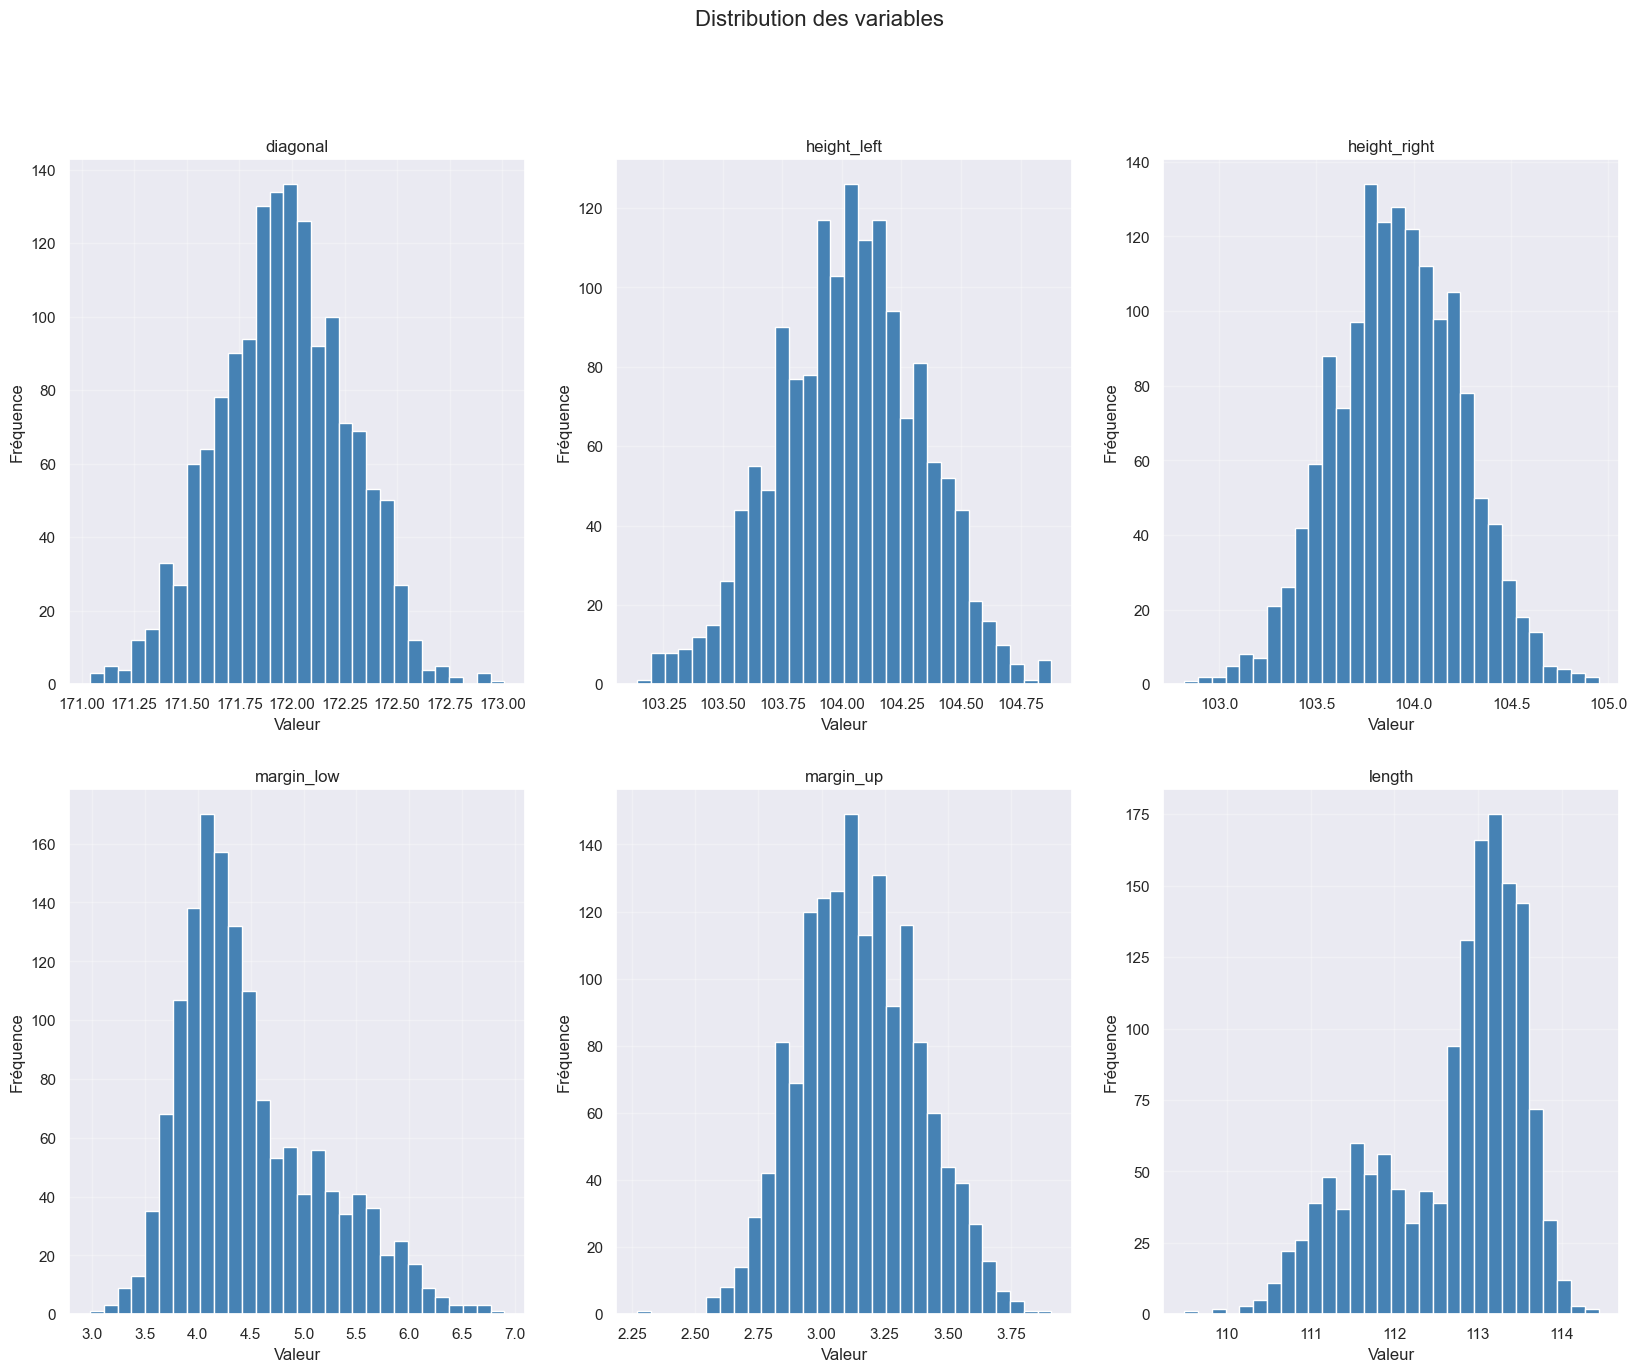

In [118]:
fig, axes = plt.subplots(2, 3, figsize=(20, 15))
axes = axes.flatten()

for i, feature in enumerate(features):
    axes[i].hist(df[feature].dropna(), bins=30,color = '#4682B4')
    
    axes[i].set_title(feature)
    axes[i].set_xlabel('Valeur')
    axes[i].set_ylabel('Fréquence')

    axes[i].grid(True, alpha=0.3)

plt.suptitle('Distribution des variables', fontsize=16)

plt.show()

On observe que visuellement, les colonnes "diagonal", "height_left", "height_right" et "margin_up" suivent des distributions en cloche assez symétriques.
La colonne "margin_low" a une distribution plus étalée vers la droite.
La colonne "length", quant à elle, est étalée vers la gauche.

Passons à la distribution par type de billet:

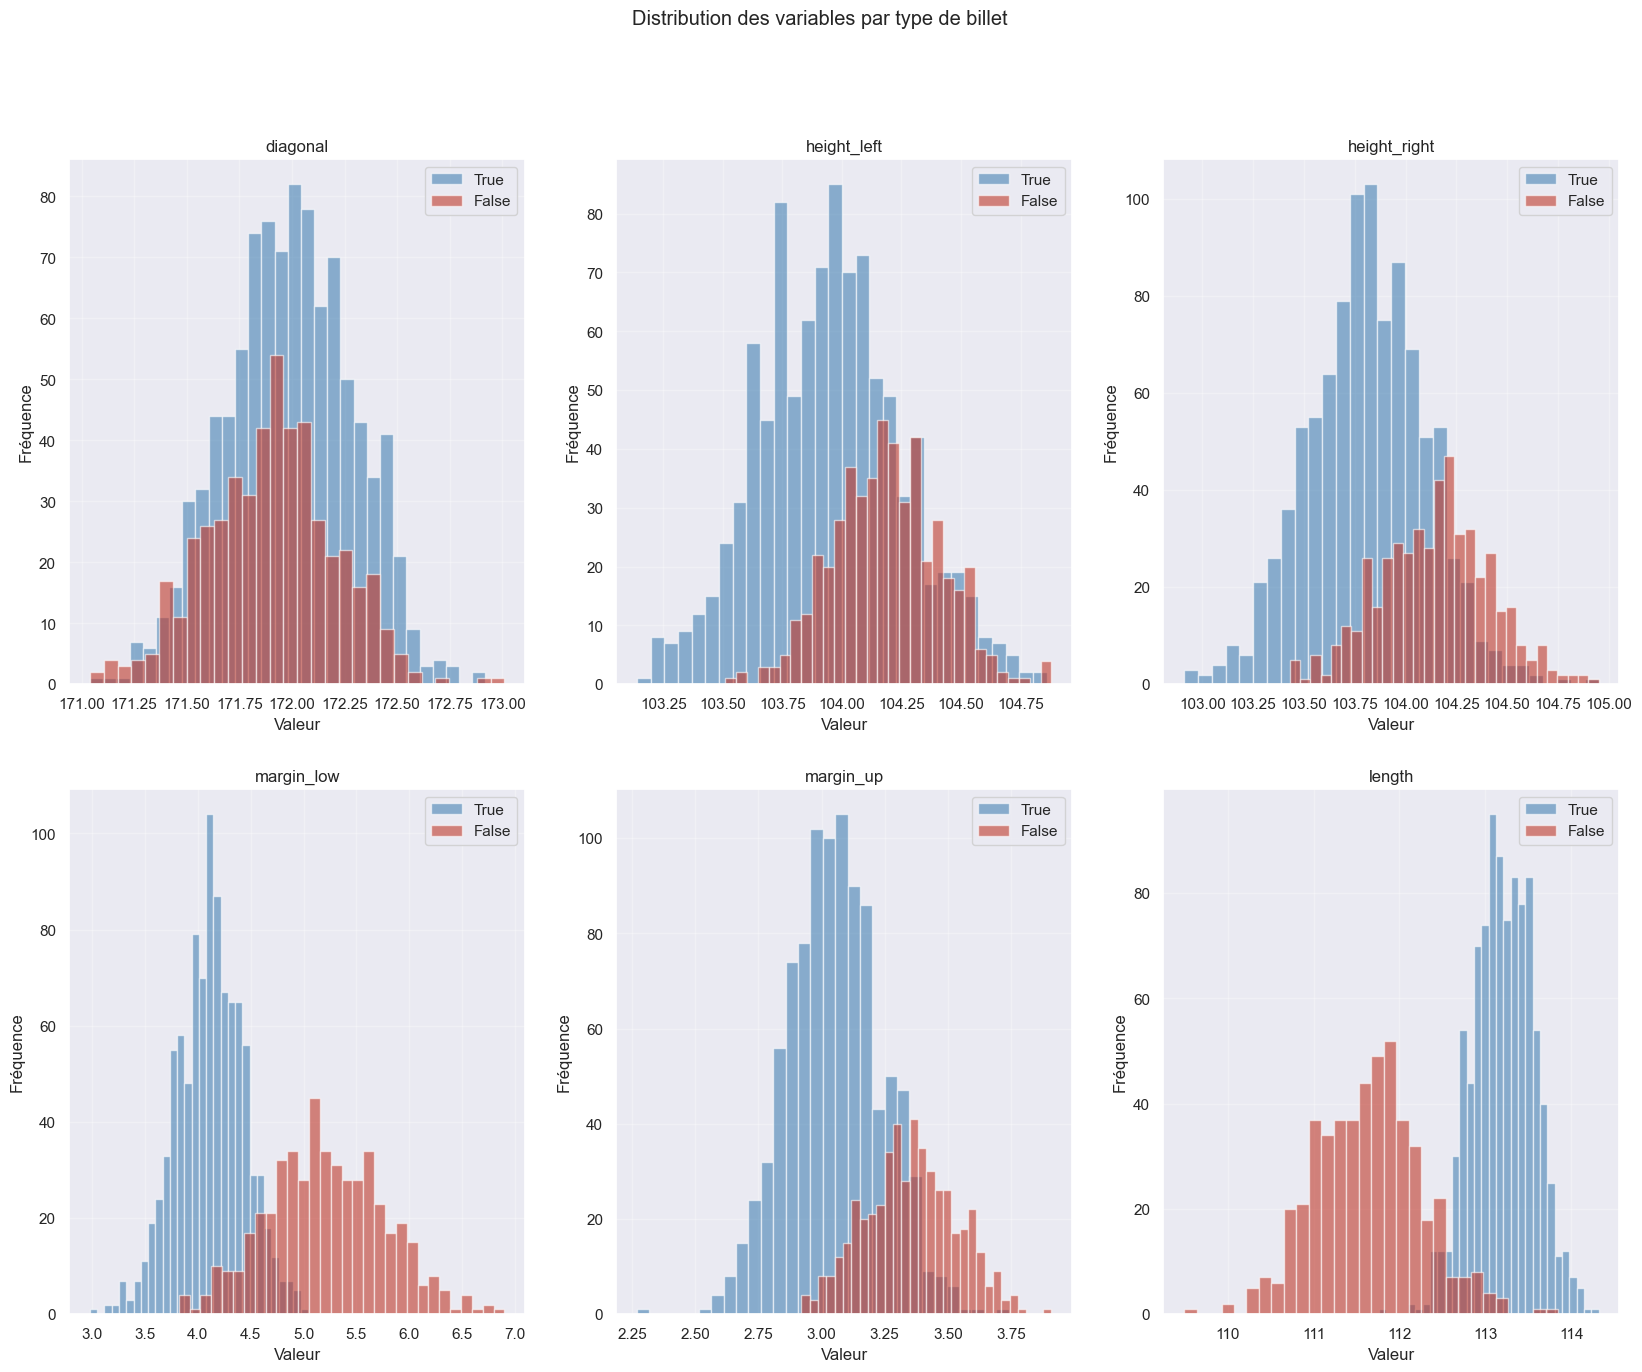

In [114]:
fig, axes = plt.subplots(2, 3, figsize=(20, 15))
axes = axes.flatten()

for i, feature in enumerate(features):
    axes[i].hist(df[df['is_genuine'] == True].dropna()[feature], bins=30, color = '#4682B4', label= "True", alpha=0.6)
    axes[i].hist(df[df['is_genuine'] == False].dropna()[feature], bins=30, color = '#C0392B', label= "False", alpha=0.6)
    
    axes[i].set_title(feature)
    axes[i].set_xlabel('Valeur')
    axes[i].set_ylabel('Fréquence')

    axes[i].legend()
    axes[i].grid(True, alpha=0.3)
    
plt.suptitle('Distribution des variables par type de billet')

plt.show()

On observe déjà une distribution des données assez différente entre les vrais et les faux billets, selon les variables étudiées:
- Les distributions des observations de la variable "diagonal" se superposent presque entièrement. Cette variable apportera probablement peu d'information au modèle, regardant la distinction des vrais billets des faux.
- La différence est plus marquante que pour la colonne “diagonal”, mais la variable “height_left” a des distributions relatives aux faux et aux vrais billets qui se chevauchent beaucoup.
- Comme pour “height_left”, “height_right ” a deux distributions plus séparées que pour la variable “diagonal”, mais la superposition reste importante.
- La différence entre les deux distributions pour la colonne “margin_low” est vraiment flagrante.  Les faux billets semblent avoir une marge basse plus importante que les vrais.
- Pour ce qui est des distributions de la colonne “margin_up”, la séparation est visible mais affiche un certain chevauchement. Là encore, les faux billets semblent avoir une marge (supérieure cette fois) plus grande que les vrais.
- Les distributions relatives à la colonne “lenght” sont quasiment parfaitement séparées. De ce que l’on peut observer visuellement grâce à ces histogrammes, c’est la variable la plus discriminante entre les vrais et les faux b. Les faux billets ont l'air nettement plus courts que vrais.
ets. 

En conclusion, “length”, “margin_low” et “margin_up” seront probablement les variables les plus intéressantes pour nos modèles


## 2.5) Boxplots

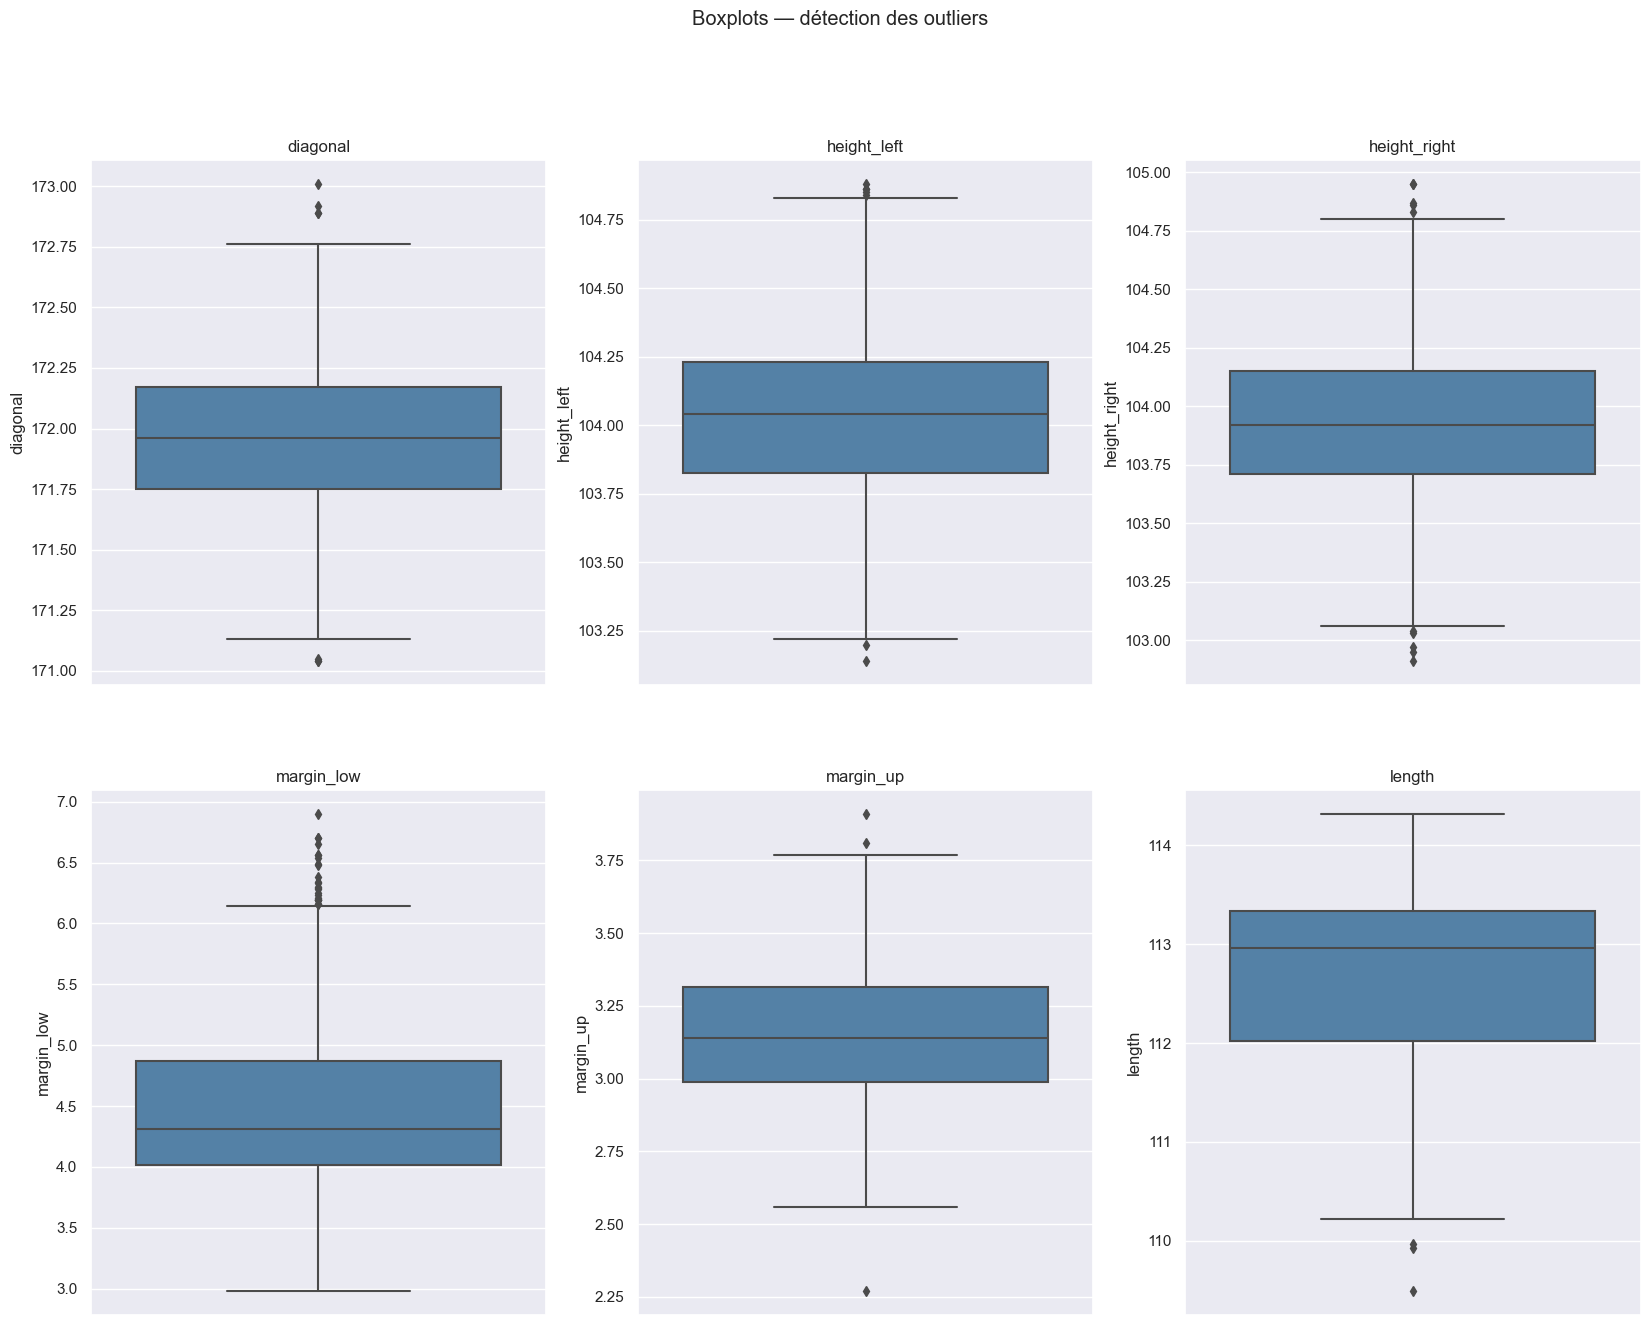

In [154]:
fig, axes = plt.subplots(2, 3, figsize=(20, 15))
axes = axes.flatten()

for i, feature in enumerate(features):
    
    sns.boxplot(
        data=df.dropna(),
        y=feature,
        color = '#4682B4',
        ax=axes[i]
    )
    
    axes[i].set_title(feature)

plt.suptitle('Boxplots — détection des outliers')

plt.show()

Globalement, le dataset a l'air plutôt propre. Il ne semble pas y avoir d'outliers qui écraseraient le reste des données et qui nécessiteraient un traitement particulier. Les quelques points extrêmes qu'on voit sont probablement de vraies mesures et non des erreurs de saisie.

Reproduisons les boxplots en incluant le type de billet:

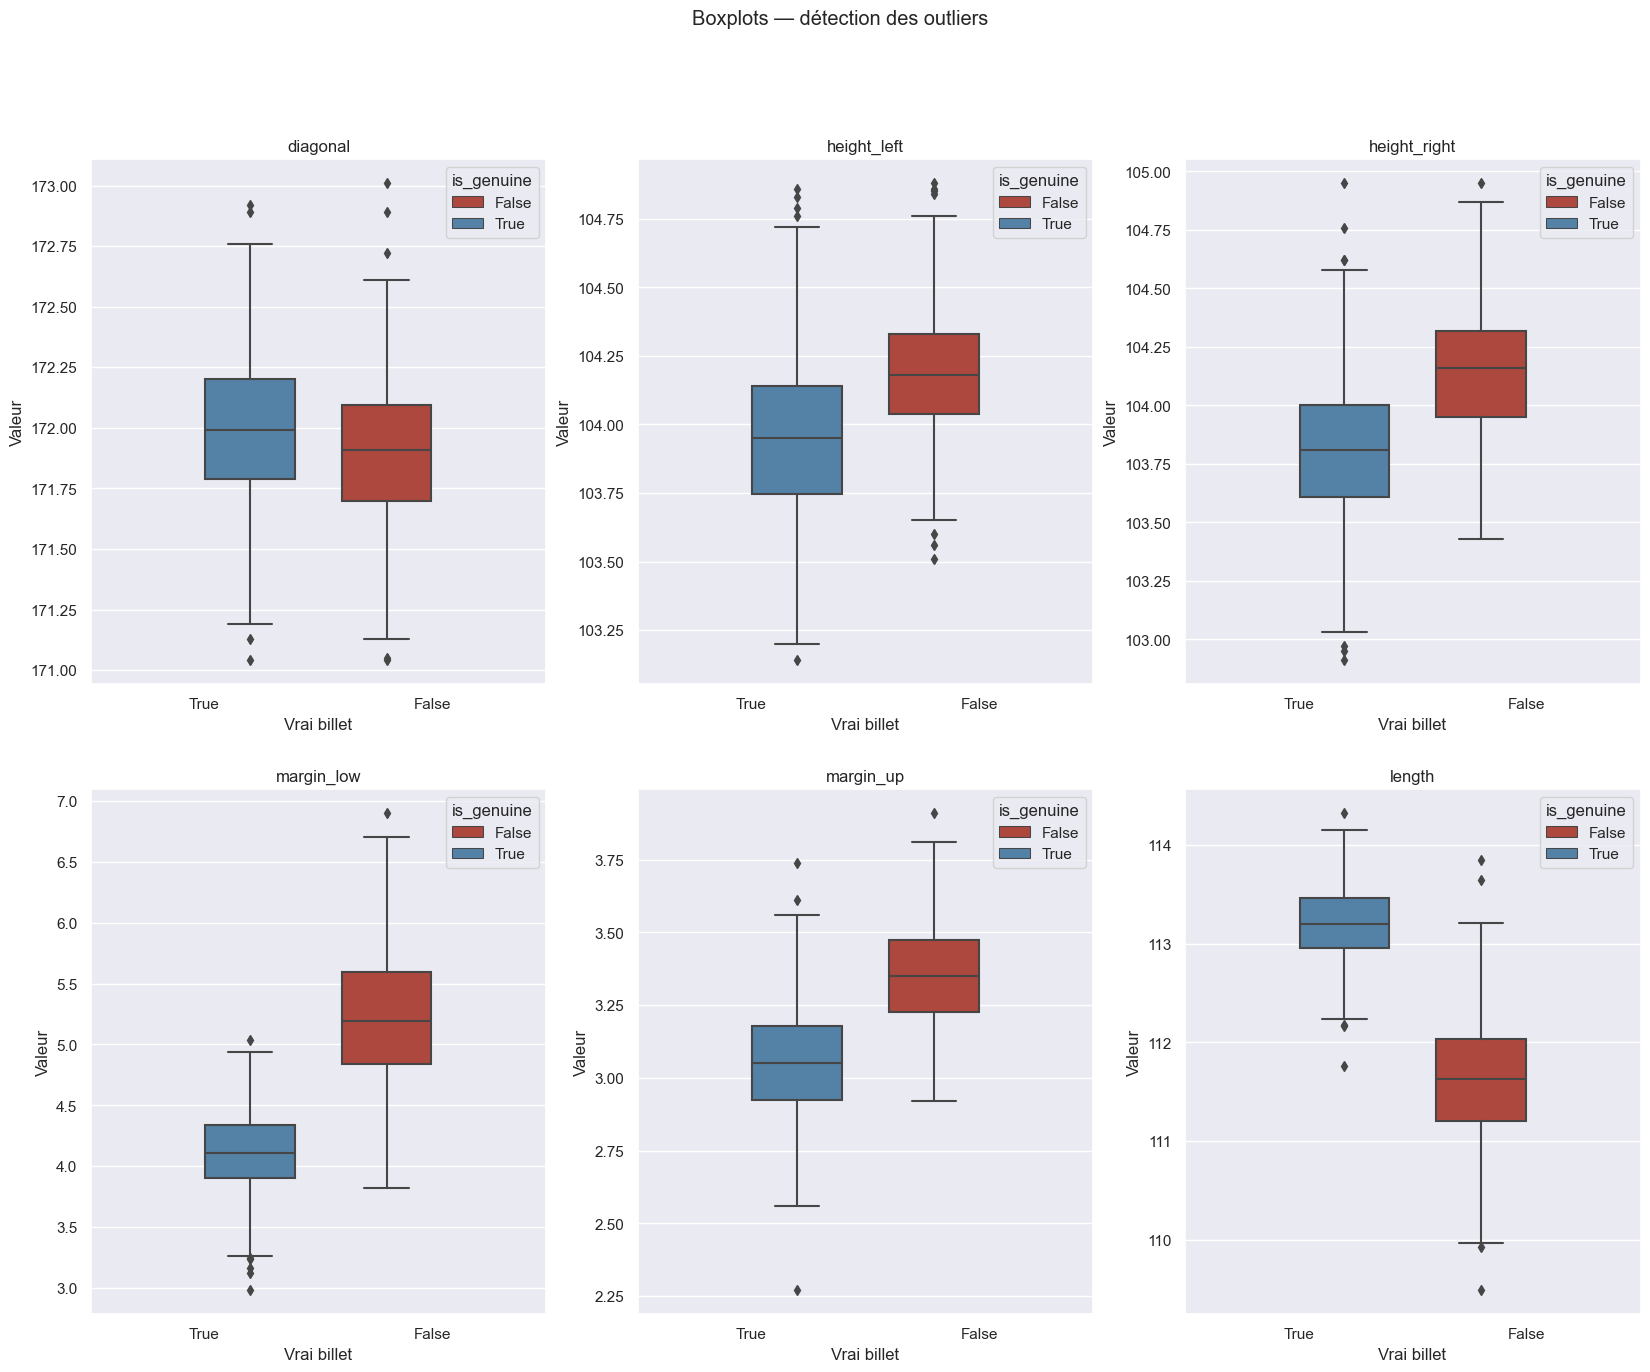

In [152]:
fig, axes = plt.subplots(2, 3, figsize=(20, 15))
axes = axes.flatten()

for i, feature in enumerate(features):
    
    sns.boxplot(
        data=df.dropna(),
        x='is_genuine',
        y=feature,
        hue='is_genuine',
        order=[True, False],
        palette={True: '#4682B4', False: '#C0392B'},
        ax=axes[i]
    )
    
    axes[i].set_title(feature)
    axes[i].set_xlabel('Type de billet')
    axes[i].set_ylabel('Valeur')

plt.suptitle('Boxplots — détection des outliers par type de billet')

plt.show()

La lecture de ce boxplot semble confirmer ce que nous avions pu observer sur l’histogramme:
- Les deux distributions sont quasiment identiques pour la colonne “diagonal”. Cette variable n'apportera probablement pas de grandes informations aux modèles.
- Pour “height_left” et “height_right”,  les faux billets sont légèrement plus hauts, mais les boîtes restent proches. Ces variables seront peu décisives.
- “margin_low” confirme sa place de deuxième meilleure séparation. Les vrais billets ont une marge plus serrée que les faux.
- La distribution de “margin_up” est aussi claire. Les faux billets ont une marge supérieure plus grande
- La colonne “length” est nettement séparée. Les vrais billets  sont de taille supérieure ou égale à 113mm, les faux ne dépassent guère les 112mm . Il n’y a pratiquement aucun chevauchement.

## 5.3 Identification des outliers par la méthode interquartile (IQR)

In [226]:
nbre_outliers = 0

for feature in features:
    Q1  = df[feature].quantile(0.25)
    Q3  = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    
    borne_inf = Q1 - 1.5 * IQR
    borne_sup = Q3 + 1.5 * IQR
    
    outliers = df[(df[feature] < borne_inf) | (df[feature] > borne_sup)]

    nbre_outliers += len(outliers)

    print(f"Voici les outliers présents dans la colonne \"{feature}\":")
    display(outliers)
    print(f"Il y a {outliers[outliers['is_genuine'] == True].shape[0]} outliers qui sont de vrais billets et {outliers[outliers['is_genuine'] == False].shape[0]} des faux.")
    print("\n")
    

Voici les outliers présents dans la colonne "diagonal":


,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length
729,True,171.04,103.84,103.64,4.22,3.36,112.70
828,True,172.92,103.55,103.94,4.78,3.27,113.55
842,True,172.89,103.77,104.24,4.12,3.01,113.72
1022,False,172.89,104.03,104.03,6.03,3.00,110.95
1142,False,171.04,104.23,104.22,4.87,3.56,111.54
1277,False,173.01,104.59,104.31,5.04,3.05,110.91
1388,False,171.05,104.09,104.50,4.72,3.10,112.44


Il y a 3 outliers qui sont de vrais billets et 4 des faux.


Voici les outliers présents dans la colonne "height_left":


,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length
0,True,171.81,104.86,104.95,4.52,2.89,112.83
224,True,172.12,103.20,103.92,4.46,3.26,113.44
292,True,172.09,103.14,103.81,4.88,3.01,113.69
1090,False,172.11,104.88,104.10,4.80,3.73,110.78
1150,False,171.79,104.86,104.34,5.39,3.14,113.02
1382,False,171.97,104.85,104.52,5.87,3.56,110.98


Il y a 3 outliers qui sont de vrais billets et 3 des faux.


Voici les outliers présents dans la colonne "height_right":


...

Il y a 0 outliers qui sont de vrais billets et 24 des faux.


Voici les outliers présents dans la colonne "margin_up":


,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length
664,True,172.05,103.70,103.75,5.04,2.27,113.55
1029,False,171.96,104.29,104.03,6.01,3.91,110.83
1270,False,171.26,104.22,104.07,4.78,3.81,112.88


Il y a 1 outliers qui sont de vrais billets et 2 des faux.


Voici les outliers présents dans la colonne "length":


,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length
1082,False,171.75,103.96,103.83,5.39,3.54,109.49
1355,False,171.68,103.89,103.70,5.97,3.03,109.97
1453,False,171.55,104.20,104.49,5.42,3.54,109.93


Il y a 0 outliers qui sont de vrais billets et 3 des faux.




In [250]:
print(f"""
Si on regarde le dataset dans son entièreté, la majorité des {nbre_outliers} outliers calculés avec la méthode IQR semblent donc être des faux billets. 
Mais selon la dimension regardée, la plus grande partie des outliers peut aussi être de vrais billets.
""")


Si on regarde le dataset dans son entièreté, la majorité des 54 outliers calculés avec la méthode IQR semblent donc être des faux billets. 
Mais selon la dimension regardée, la plus grande partie des outliers peut aussi être de vrais billets.



Supprimer ces outliers serait probablement contre-productif pour notre objectif. On cherche à détecter les faux billets, et certains faux billets auront précisément des dimensions extrêmes. Si on les supprime à l'entraînement, le modèle ne saura pas les reconnaître en production. Nous allons donc les conserver. Qui plus est, il est bien visible sur les boxplots que les outliers de notre dataset sont des valeurs extrêmes et non des valeurs aberrantes. 

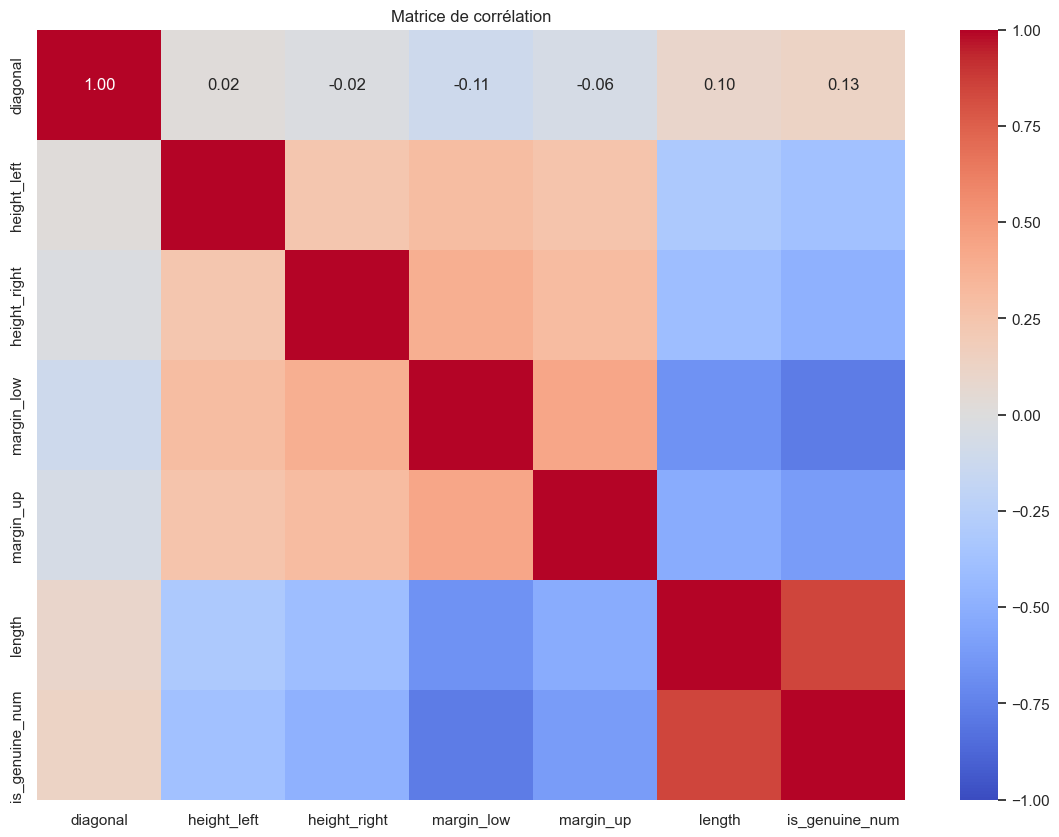

In [241]:
df['is_genuine_num'] = df['is_genuine'].astype(int)

fig, ax = plt.subplots(figsize=(14, 10))

corr_matrix = df[features + ['is_genuine_num']].corr().round(2)

sns.heatmap(corr_matrix, 
            annot=True, 
            fmt='.2f',
            cmap='coolwarm',
            vmin=-1,
            vmax=1,
            ax=ax)

ax.set_title('Matrice de corrélation')

plt.show()

Encore une fois, la matrice de corrélation semble supporter ce que nous avions observé plus tôt. Si on regarde les variables corrélées à "is_genuine", de la plus forte à la plus faible corrélation:
- "length" semble être de loin la plus corrélée, les vrais billets sont effectivement plus longs.
- "margin_low" présente une forte corrélation négative, les faux billets ont une marge basse plus grande.
- "margin_up" présente une corrélation négative notable
- "height_right" affiche quant à elle une corrélation négative modérée
- il en va de même pour "height_left", une corrélation négative modérée et légèrement plus faible que pour "height_right"
- pour finir "diagonale" affiche une corrélation quasi nulle, cette variable n'apportera presque rien à nos modèles

In [248]:
print("Corrélations avec is_genuine :")
print(corr_matrix['is_genuine_num'].drop('is_genuine_num').sort_values())

Corrélations avec is_genuine :
margin_low     -0.78
margin_up      -0.61
height_right   -0.49
height_left    -0.38
diagonal        0.13
length          0.85
Name: is_genuine_num, dtype: float64


# 3) Prétraitement

Le but est de transformer tes données brutes (les valeurs mesurées des billets) en données que les algorithmes de Machine Learning peuvent comprendre efficacement.


In [252]:
margin_low_mediane_true = df[df['is_genuine'] == True]['margin_low'].median()
margin_low_mediane_false = df[df['is_genuine'] == False]['margin_low'].median()

df.loc[(df['margin_low'].isnull()) & (df['is_genuine'] == True), 'margin_low'] = margin_low_mediane_true
df.loc[(df['margin_low'].isnull()) & (df['is_genuine'] == False), 'margin_low'] = margin_low_mediane_false

Il y a 0 dans la colonne "margin_low".


In [254]:
print(f"Il y a {df['margin_low'].isnull().sum()} valeurs manquantes dans la colonne \"margin_low\".")

Il y a 0 valeurs manquantes dans la colonne "margin_low".


D'abord, il faut séparer les variables explicatives et la cible :

X = les mesures du billet (longueur, hauteur, diagonales…)

y = l’étiquette (vrai ou faux)

➡️ Pourquoi ?
Parce que le modèle doit apprendre à prédire y en fonction de X.

Nous avons déjà créé une variable "features", mais re-créons là ici pour avoir un code plus propre:

In [259]:
features = ['diagonal', 
            'height_left', 
            'height_right',
            'margin_low', 
            'margin_up', 
            'length']

In [265]:
df.drop(labels='is_genuine_num', axis=1, inplace=True)

La colonne "is_genuine" est de type booléen. Les modèles de machine learning n'accèptent que des valeurs numériques. Nous devons donc la convertir au bon format.

In [270]:
df['is_genuine'] = df['is_genuine'].astype(int)

In [272]:
df.head()

,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length
0,1,171.81,104.86,104.95,4.52,2.89,112.83
1,1,171.46,103.36,103.66,3.77,2.99,113.09
2,1,172.69,104.48,103.50,4.40,2.94,113.16
3,1,171.36,103.91,103.94,3.62,3.01,113.51
4,1,171.73,104.28,103.46,4.04,3.48,112.54


In [274]:
X = df[features]
y = df["is_genuine"] 

Autre point important : on entraîne toujours le modèle sur un morceau des données, et on teste sur un autre qu’il n’a jamais vu.

➡️ Pourquoi ?
Pour éviter le sur-apprentissage (le modèle apprend par cœur sans savoir généraliser).

In [276]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Enfin, on met toutes les variables sur la même échelle (moyenne = 0, écart-type = 1).

➡️ Pourquoi ?
Parce que certains modèles, comme le KNN ou la Régression Logistique, sont sensibles aux différences d’échelle.
Sans standardisation, la variable la plus grande numériquement prend trop d’importance.

In [279]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4) Modélisation

Dans tous domaines, vous ne pouvez pas progresser si vous ne comprenez pas comment vos outils fonctionnent.

Avant d'utiliser les modèles mathématiques qui suivent, je vous recommande donc de visionner les vidéos suivantes:
* [StatQuest: Logistic Regression](https://www.youtube.com/watch?v=yIYKR4sgzI8)
* [StatQuest: K-nearest neighbors, Clearly Explained](https://youtu.be/HVXime0nQeI)
* [StatQuest: Random Forests Part 1 - Building, Using and Evaluating](https://youtu.be/J4Wdy0Wc_xQ)
* [StatQuest: Random Forests Part 2: Missing data and clustering](https://www.youtube.com/watch?v=sQ870aTKqiM)
* [StatQuest: K-means clustering](https://youtu.be/4b5d3muPQmA)

In [281]:
from sklearn.model_selection import GridSearchCV

In [309]:
from sklearn.linear_model import LogisticRegression

# 1) Initialisez une régression logistic.
    # Quels sont les paramètres ajustables de ce modèle ?
    # Bien que vous puissez laisser la majorité d'entre eux par défaut,
    # il vaut mieux, à minima, ajuster `max_iter` pour plafonner le temps de calcul.

lr_params = {
    'penalty': ['l2', None],
    'solver': ['lbfgs']
}

lr_model = LogisticRegression(random_state = 42, max_iter = 500)

lr = GridSearchCV(lr_model, lr_params, cv = 5, scoring='roc_auc', verbose = 1)

# 2) Entrainez le modèle avec vos données X_train et y_train
lr.fit(X_train_scaled, y_train)

print("La meilleure valeur des paramètres est :", lr.best_params_)
print("Le meilleur score obtenu est :", lr.best_score_)
print("Le meilleur modèle est :", lr.best_estimator_)

# 3) Utiliser la régression logistique pour déterminer les vrais / faux billets de X_test.
y_pred_lr = lr.predict(X_test_scaled)

Fitting 5 folds for each of 2 candidates, totalling 10 fits
La meilleure valeur des paramètres est : {'penalty': 'l2', 'solver': 'lbfgs'}
Le meilleur score obtenu est : 0.9986704653371319
Le meilleur modèle est : LogisticRegression(max_iter=500, random_state=42)


In [289]:
from sklearn.neighbors import KNeighborsClassifier

# Répéter les même étapes que pour la régression logistique mais avec le KNN.

knn_params = {
    'n_neighbors': [1, 3, 5, 7, 9, 11, 13, 15, 17, 19]
}

knn_model = KNeighborsClassifier()

knn = GridSearchCV(knn_model, knn_params, cv=5, scoring='roc_auc', verbose=1)

knn.fit(X_train_scaled, y_train)

print("La meilleure valeur des paramètres est :", knn.best_params_)
print("Le meilleur score obtenu est :", knn.best_score_)
print("Le meilleur modèle est :", knn.best_estimator_)

y_pred_knn = knn.predict(X_test_scaled)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
La meilleure valeur des paramètres est : {'n_neighbors': 13}
Le meilleur score obtenu est : 0.9953782842671732
Le meilleur modèle est : KNeighborsClassifier(n_neighbors=13)


In [311]:
from sklearn.ensemble import RandomForestClassifier

# hum... devinez ce qu'il faut faire 😁.

rf_params = {
    'n_estimators': [20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 150],
    'max_depth': [2, 3, 5, 10, None]
}

rf_model = RandomForestClassifier(random_state = 42)

rf = GridSearchCV(rf_model, rf_params, cv=5, scoring='roc_auc', verbose=1)

rf.fit(X_train_scaled, y_train)

print("La meilleure valeur des paramètres est :", rf.best_params_)
print("Le meilleur score obtenu est :", rf.best_score_)
print("Le meilleur modèle est :", rf.best_estimator_)

y_pred_rf = rf.predict(X_test_scaled)

Fitting 5 folds for each of 60 candidates, totalling 300 fits
La meilleure valeur des paramètres est : {'max_depth': 3, 'n_estimators': 120}
Le meilleur score obtenu est : 0.9995093383982272
Le meilleur modèle est : RandomForestClassifier(max_depth=3, n_estimators=120, random_state=42)


In [328]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Attention ! Cet algo est très différents de ceux utilisés précédemment.
# Peux-tu voir les différences ?
# Du coup, cet algo est-il utile (voir pertinent) pour cette étude ?
print("""
Le k-means est un modèle non supervisé, on ne peut donc pas utiliser y_train pendant l'entraînement. Mais on peut s'en servir pour identifier à quel 
cluster correspondent les vrais billets et à quel cluster correspond les faux. On peut par la suite utiliser les centroïdes pour réaliser une 
prédiction.
""")


Le k-means est un modèle non supervisé, on ne peut donc pas utiliser y_train pendant l'entraînement. Mais on peut s'en servir pour identifier à quel 
cluster correspondent les vrais billets et à quel cluster correspond les faux. On peut par la suite utiliser les centroïdes pour réaliser une 
prédiction.



Commençons par vérifier si k-mean identifie le bon nombre de clusters.

C:\Users\alexandre.low-kam\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(


Silhouette score pour K = 2 : 0.35


C:\Users\alexandre.low-kam\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(


Silhouette score pour K = 3 : 0.21


C:\Users\alexandre.low-kam\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(


...

Silhouette score pour K = 8 : 0.14


C:\Users\alexandre.low-kam\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(


Silhouette score pour K = 9 : 0.14


C:\Users\alexandre.low-kam\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(


Silhouette score pour K = 10 : 0.14


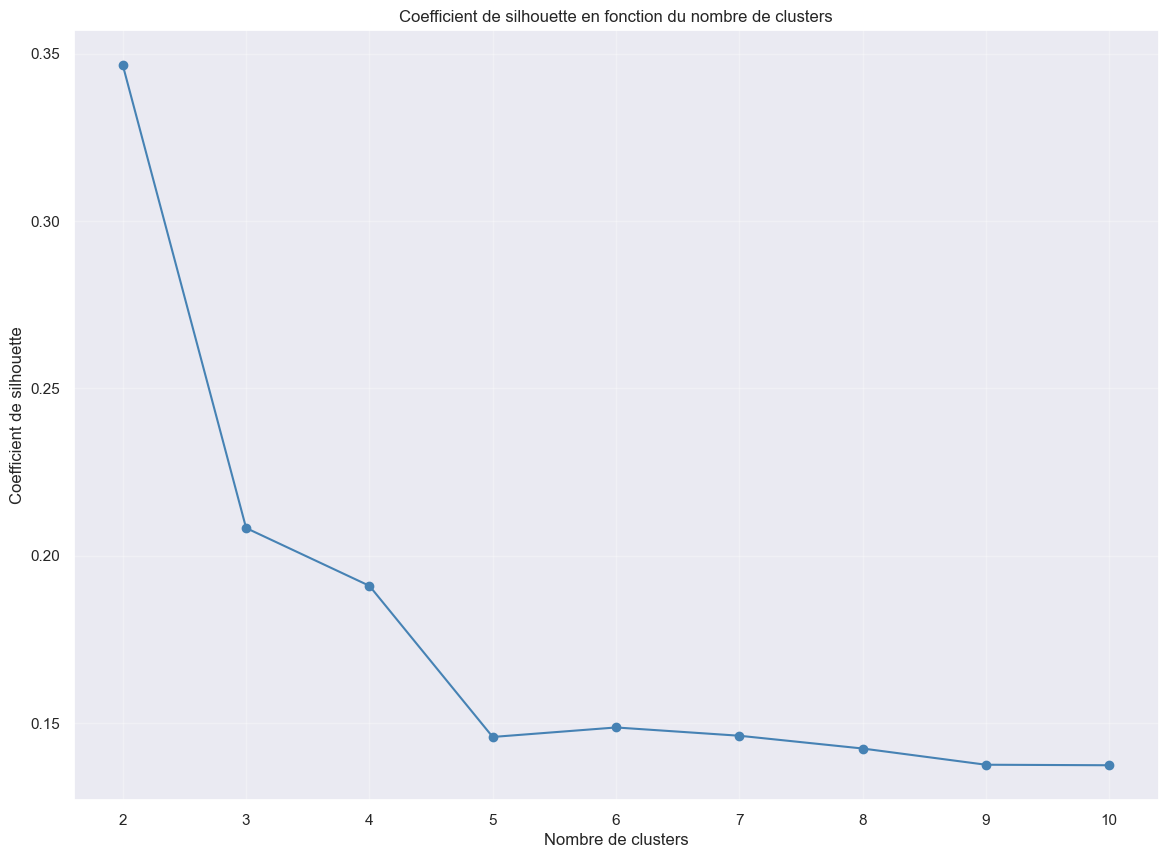

In [317]:
silhouette_scores = []
K_values = range(2, 11)

for k in K_values:
    km_test = KMeans(n_clusters = k, random_state = 42, n_init = 'auto')
    km_test.fit(X_train_scaled)
    labels = km_test.predict(X_train_scaled)
    score = silhouette_score(X_train_scaled, labels)
    silhouette_scores.append(score)
    print(f"Silhouette score pour K = {k} : {score:.2f}")

plt.figure(figsize=(14, 10))

plt.plot(K_values, silhouette_scores, marker='o', color='#4682B4')

plt.xlabel('Nombre de clusters')
plt.ylabel('Coefficient de silhouette')
plt.title('Coefficient de silhouette en fonction du nombre de clusters')
plt.grid(True, alpha=0.3)
plt.show()

In [319]:
print(f"\nLe nombre optimal de clusters est bien de {K_values[silhouette_scores.index(max(silhouette_scores))]}, comme on pouvait s'y attendre.")


Le nombre optimal de clusters est bien de 2, comme on pouvait s'y attendre.


In [371]:
km = KMeans(n_clusters = 2, random_state = 42, n_init='auto')
km.fit(X_train_scaled)

cluster_train = km.predict(X_train_scaled)

df_clusters = pd.DataFrame({'cluster': cluster_train, 'is_genuine': y_train.values})

print(round(df_clusters.groupby('cluster')['is_genuine'].mean() * 100, 2))

for index in round(df_clusters.groupby('cluster')['is_genuine'].mean() * 100, 2).index:
    print(f"Le cluster {index} est composé à {round(df_clusters.groupby('cluster')['is_genuine'].mean() * 100, 2)[index]} % de vrais billets.")


C:\Users\alexandre.low-kam\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(


cluster
0    98.41
1     1.57
Name: is_genuine, dtype: float64
Le cluster 0 est composé à 98.41 % de vrais billets.
Le cluster 1 est composé à 1.57 % de vrais billets.


Il semblerait donc que le cluster 0 correspond aux vrais billets et le cluster 1 aux faux. Nous devriont donc créer un dictionaire pour faire en sorte que les numéros des clusters du modèle correspondent bien aux valeurs de "is_genuine".

In [373]:
cluster_train[:10]

array([0, 0, 1, 1, 0, 0, 1, 1, 0, 0])

In [375]:
mapping = {0: 1, 1: 0}

In [377]:
cluster_train = pd.Series(cluster_train).map(mapping).values

In [379]:
cluster_train[:10]

array([1, 1, 0, 0, 1, 1, 0, 0, 1, 1], dtype=int64)

In [381]:
clusters_test = km.predict(X_test_scaled)
y_pred_km = pd.Series(clusters_test).map(mapping).values

# Sélection du meilleur modèle

Mais alors, quel est le meilleur modèle pour résoudre ce problème ?

Pour répondre à cette question, il vous faut bien comprendre l'intérêt de chacune des métriques d'évaluation qui existent pour ce type de problème.

Vous me voyez venir... 😎 : StatQuest !!! 🤩
* [Machine Learning Fundamentals: Sensitivity and Specificity
](https://youtu.be/vP06aMoz4v8)
* [Machine Learning Fundamentals: The Confusion Matrix](https://youtu.be/Kdsp6soqA7o)
* [ROC and AUC, Clearly Explained!](https://youtu.be/4jRBRDbJemM)

Vous avez aussi des petits modules sympathiques sur Sklearn qui vous machent grandement le travail:
* [Confusion Matrix](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html)
* [Confusion Matrix Display](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html)
* [Classification Report](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html)

A vous de jouer ! 🚀

In [383]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

# C'est là qu'on voit qui sont les bons 😉!

In [385]:
modeles = {
    'Régression Logistique': y_pred_lr,
    'KNN': y_pred_knn,
    'Random Forest': y_pred_rf,
    'K-Means': y_pred_km
}

In [475]:
for nom, y_pred in modeles.items():
    print('Modèle: ', nom)
    print('Accuracy', accuracy_score(y_test, y_pred))
    print('Précision', precision_score(y_test, y_pred, pos_label=0))
    print('Rappel', recall_score(y_test, y_pred, pos_label=0))
    print('F1-score', f1_score(y_test, y_pred, pos_label=0))
    print('ROC AUC score', roc_auc_score(y_test, y_pred))
    print("\n")

Modèle:  Régression Logistique
Accuracy 0.9933333333333333
Précision 1.0
Rappel 0.9818181818181818
F1-score 0.9908256880733944
ROC AUC score 0.9909090909090909


Modèle:  KNN
Accuracy 0.9866666666666667
Précision 1.0
Rappel 0.9636363636363636
F1-score 0.9814814814814815
ROC AUC score 0.9818181818181818


Modèle:  Random Forest
Accuracy 0.99
Précision 1.0
Rappel 0.9727272727272728
F1-score 0.9861751152073733
ROC AUC score 0.9863636363636364


Modèle:  K-Means
Accuracy 0.99
Précision 0.9819819819819819
Rappel 0.990909090909091
F1-score 0.9864253393665158
ROC AUC score 0.9901913875598087




In [477]:
resultats = []

for nom, y_pred in modeles.items():
    resultats.append({
        'Modele': nom,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, pos_label=0),
        'Rappel': recall_score(y_test, y_pred, pos_label=0),
        'F1-score': f1_score(y_test, y_pred, pos_label=0),
        'ROC AUC score': roc_auc_score(y_test, y_pred)
    })

df_resultats = pd.DataFrame(resultats).round(4)

In [479]:
df_resultats

,Modele,Accuracy,Precision,Rappel,F1-score,ROC AUC score
0,Régression Logistique,0.9933,1.000,0.9818,0.9908,0.9909
1,KNN,0.9867,1.000,0.9636,0.9815,0.9818
2,Random Forest,0.9900,1.000,0.9727,0.9862,0.9864
3,K-Means,0.9900,0.982,0.9909,0.9864,0.9902


In [481]:
print(f"Le modèle avec le meilleur score pour l'accuracy est: {df_resultats[df_resultats['Accuracy'] == df_resultats['Accuracy'].max()]['Modele'].values[0]} ")
print(f"Le modèle avec le meilleur score pour la précision est: {df_resultats[df_resultats['Precision'] == df_resultats['Precision'].max()]['Modele'].values[0]} ")
print(f"Le modèle avec le meilleur score pour le rappel est: {df_resultats[df_resultats['Rappel'] == df_resultats['Rappel'].max()]['Modele'].values[0]} ")
print(f"Le modèle avec le meilleur score pour le F1-score est: {df_resultats[df_resultats['F1-score'] == df_resultats['F1-score'].max()]['Modele'].values[0]} ")
print(f"Le modèle avec le meilleur score pour le ROC AUC score est: {df_resultats[df_resultats['ROC AUC score'] == df_resultats['ROC AUC score'].max()]['Modele'].values[0]} ")

Le modèle avec le meilleur score pour l'accuracy est: Régression Logistique 
Le modèle avec le meilleur score pour la précision est: Régression Logistique 
Le modèle avec le meilleur score pour le rappel est: K-Means 
Le modèle avec le meilleur score pour le F1-score est: Régression Logistique 
Le modèle avec le meilleur score pour le ROC AUC score est: Régression Logistique 


Compte tenu de nos objectifs et du contexte du projet, on peut considérer que le rappel est la métrique la plus importante à observer. En effet, c'est une métrique dont la fonction est de minimiser les faux négatifs, quand les conséquences de manquer des instances positives sont graves. Dans le cadre de la détection de faux billets, c'est bien de minimiser la possibilité de passer à côté de faux billets dont il est question.De ce point de vu là, c'est le K-Means qui semble le mieux performer, suivi de la régression logistique.
La précision et le F1-score (la moyenne harmonique entre précision et rappel) ont dans ce contexte particulier moins d'importance pour nous. 
Reste donc l'accuracy et le ROC AUC score pour départager nos modèles. C'est la régression logistique qui performe le mieux pour ces deux métriques.
Confirmons nos observations avec les matrices de confusion.

In [483]:
confusion_matrix(y_test, y_pred_lr)

array([[108,   2],
       [  0, 190]], dtype=int64)

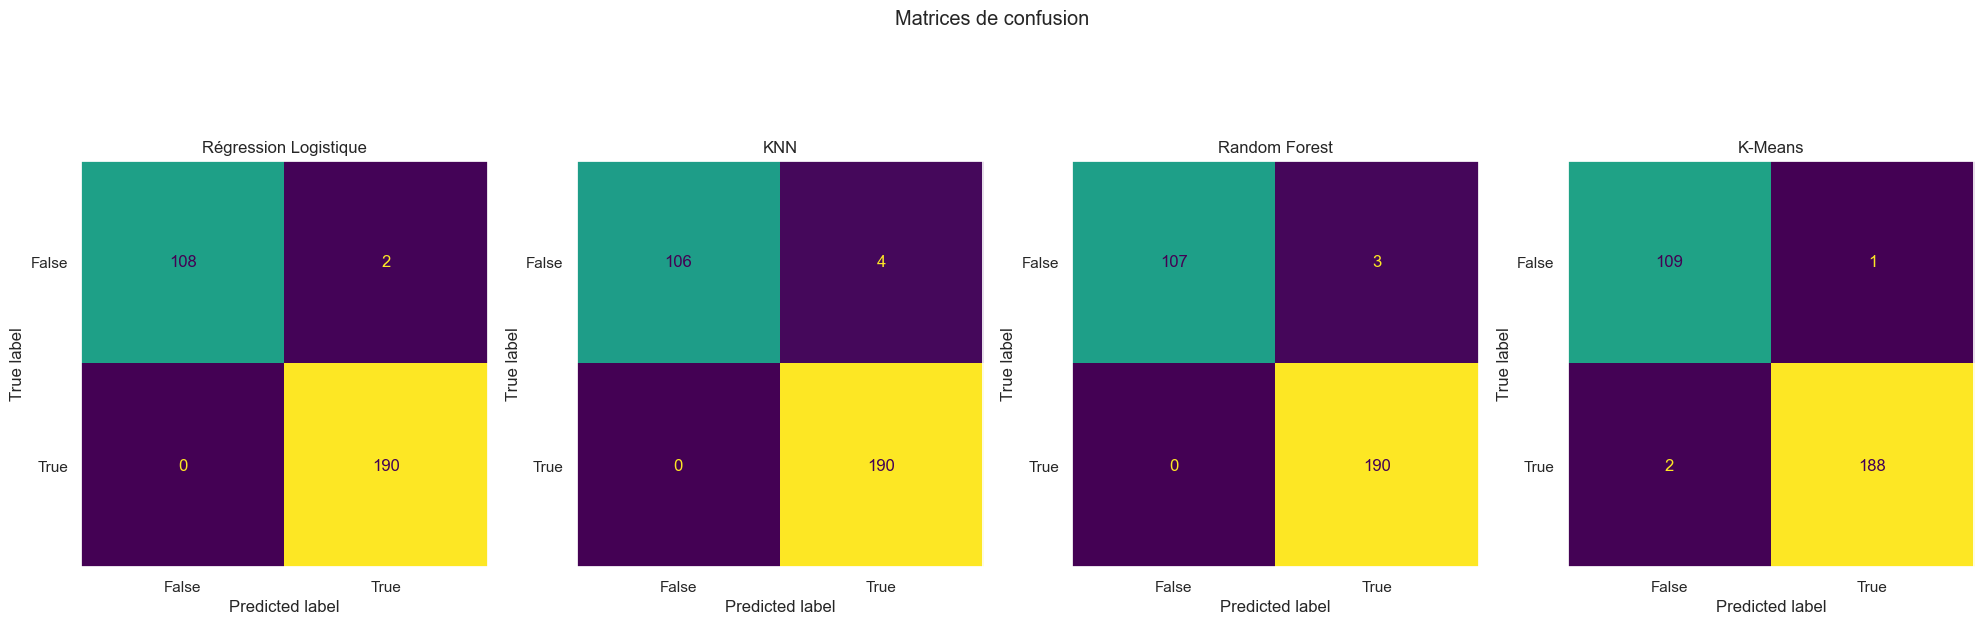

In [489]:
fig, axes = plt.subplots(1, 4, figsize=(20, 7))

for i, nom in enumerate(modeles):
    cm = confusion_matrix(y_test, modeles[nom])
    disp = ConfusionMatrixDisplay(cm, display_labels=['False', 'True'])
    disp.plot(ax=axes[i], colorbar=False)
    
    axes[i].set_title(nom)

    axes[i].grid(False)

plt.suptitle('Matrices de confusion')

plt.tight_layout()
plt.show()

**Observations par matrice**

Régression Logistique:
- 108 faux billets correctement détectés
- 2 faux billets manqués (classés comme vrais)
- 0 vrai billet classé comme faux
- 190 vrais billets correctement identifiés

KNN:
- 106 faux billets correctement détectés
- 4 faux billets manqués
- 0 vrai billet classé comme faux
- 190 vrais billets correctement identifiés

Random Forest:
- 107 faux billets correctement détectés
- 3 faux billets manqués
- 0 vrai billet classé comme faux
- 190 vrais billets correctement identifiés

K-Means:
- 109 faux billets correctement détectés
- 1 faux billet manqué
- 2 vrais billets classés comme faux
- 188 vrais billets correctement identifiés

In [506]:
for nom, y_pred in modeles.items():
    print(f"{nom}", ": ")
    print("\n")
    print(classification_report(y_test, y_pred, target_names=['False', 'True']))
    print("\n")

Régression Logistique : 


              precision    recall  f1-score   support

       False       1.00      0.98      0.99       110
        True       0.99      1.00      0.99       190

    accuracy                           0.99       300
   macro avg       0.99      0.99      0.99       300
weighted avg       0.99      0.99      0.99       300



KNN : 


              precision    recall  f1-score   support

       False       1.00      0.96      0.98       110
        True       0.98      1.00      0.99       190

    accuracy                           0.99       300
   macro avg       0.99      0.98      0.99       300
weighted avg       0.99      0.99      0.99       300



Random Forest : 


              precision    recall  f1-score   support

       False       1.00      0.97      0.99       110
        True       0.98      1.00      0.99       190

    accuracy                           0.99       300
   macro avg       0.99      0.99      0.99       300
weighted avg   

Le rapport de classification nous confirme ce que nous avions observé plus tôt regardant les rappels relatifs aux faux billets:
- Régression logistique : 0.98
- KNN : 0.96
- Random Forest : 0.97
- K-Means : 0.99 (toujours le meilleur rappel sur les faux billets)

# Sauvegarde du meilleur modèle

**_ATTENTION_** :
```
Sauvegarder un modèle implique de sauvegarder aussi les étapes de préprocessing des données.
Dans votre cas, vous devez donc inclure, à minima, votre StandardScaler.
```
Voir [`make_pipeline`](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.make_pipeline.html) pour plus d'infos.

In [516]:
from sklearn.pipeline import make_pipeline
import joblib

# Utilisez make_pipeline pour inclure toutes les étapes nécessaires
# à la prédiction de si un billet est vrai ou faux.

pipeline = make_pipeline(StandardScaler(), lr.best_estimator_)

pipeline.fit(X_train, y_train)

y_pred_pipeline = pipeline.predict(X_test)
print("L'accuracy du pipeline est de", round(accuracy_score(y_test, y_pred_pipeline), 2))

# Sauvegardez votre modèle à l'aide de la librairie joblib.
joblib.dump(pipeline, 'modele_billets.pkl')

L'accuracy du pipeline est de 0.99


['modele_billets.pkl']